In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.1
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001


BASE_DIR = Path("../Dados")
TREINO_DIR = BASE_DIR / "Treino"
VALIDACAO_DIR = BASE_DIR / "Validacao"
TESTE_DIR = BASE_DIR / "Teste"

MODELOS_DIR = Path("../models")
MODELOS_DIR.mkdir(exist_ok=True)

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(exist_ok=True)

print(f"Imagem: {IMG_SIZE}, Batch: {BATCH_SIZE}, Épocas: {EPOCHS}")

Imagem: (128, 128), Batch: 32, Épocas: 15


In [ ]:

from PIL import Image as PILImage
import os

def verificar_imagens(base_dir):

    corrompidas = []
    total = 0
    
    for classe in ["nowildfire", "wildfire"]:
        pasta = base_dir / classe
        for arq in pasta.iterdir():
            total += 1
            try:
                with PILImage.open(arq) as img:
                    img.verify()  
                
                with PILImage.open(arq) as img:
                    img.load()
                  
                    if img.format not in ["JPEG", "PNG"]:
                        corrompidas.append(arq)
            except Exception as e:
                corrompidas.append(arq)
    
    return corrompidas, total

print(" Verificando integridade das imagens (pode demorar 1-2 min)...\n")

for nome, pasta in [("Treino", TREINO_DIR), ("Validacao", VALIDACAO_DIR), ("Teste", TESTE_DIR)]:
    corrompidas, total = verificar_imagens(pasta)
    print(f"{nome}: {len(corrompidas)}/{total} corrompidas")
    
    
    for arq in corrompidas:
        print(f"  Removendo: {arq.name}")
        arq.unlink() 

print("\n Limpeza concluída!")

🔍 Verificando integridade das imagens (pode demorar 1-2 min)...

Treino: 0/30249 corrompidas
Validacao: 0/6300 corrompidas
Teste: 1/6300 corrompidas
  Removendo: -73.15884,46.38819.jpg

✅ Limpeza concluída!


In [14]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    TREINO_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDACAO_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TESTE_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"\nClasses: {train_ds.class_names}")

Found 30249 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.
Found 6299 files belonging to 2 classes.

Classes: ['nowildfire', 'wildfire']


In [ ]:

AUTOTUNE = tf.data.AUTOTUNE

def normalizar(img, label):
    return tf.cast(img, tf.float32) / 255.0, label

train_ds = train_ds.map(normalizar, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(normalizar, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(normalizar, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

print("Pipelines de dados prontos ")

Pipelines de dados prontos ✅


In [ ]:
def criar_modelo_baseline(input_shape=(128, 128, 3)):
   
    modelo = models.Sequential([
        layers.Input(shape=input_shape),

       
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

       
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

      
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="BaselineCNN")

    return modelo

modelo_baseline = criar_modelo_baseline()
modelo_baseline.summary()

Model: "BaselineCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelo_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("Modelo compilado ")

Modelo compilado ✅


In [ ]:
checkpoint = callbacks.ModelCheckpoint(
    filepath=MODELOS_DIR / "modelo_baseline_melhor.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

print("Callbacks configurados")

Callbacks configurados ✅


In [17]:
import time

inicio = time.time()

historico_baseline = modelo_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop],
    verbose=1,
)

tempo_total = (time.time() - inicio) / 60
print(f"\n Tempo total: {tempo_total:.2f} minutos")

Epoch 1/15
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7628 - loss: 22.4269
Epoch 1: val_accuracy improved from None to 0.51063, saving model to ../models/modelo_baseline_melhor.keras

Epoch 1: finished saving model to ../models/modelo_baseline_melhor.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.7038 - loss: 9.2683 - val_accuracy: 0.5106 - val_loss: 8.9166
Epoch 2/15
945/946 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5336 - loss: 6.6079
Epoch 2: val_accuracy improved from 0.51063 to 0.56365, saving model to ../models/modelo_baseline_melhor.keras

Epoch 2: finished saving model to ../models/modelo_baseline_melhor.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.5455 - loss: 6.4006 - val_accuracy: 0.5637 - val_loss: 3.8368
Epoch 3/15
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7117 - loss: 5.1973
Epoch 3: val_accuracy did not improve from 0.56365
946/946 ━━━━━━━━━━━━━━━━━━━━ 44s 46ms/step - accuracy: 0.7906 - loss: 6.3583 - val

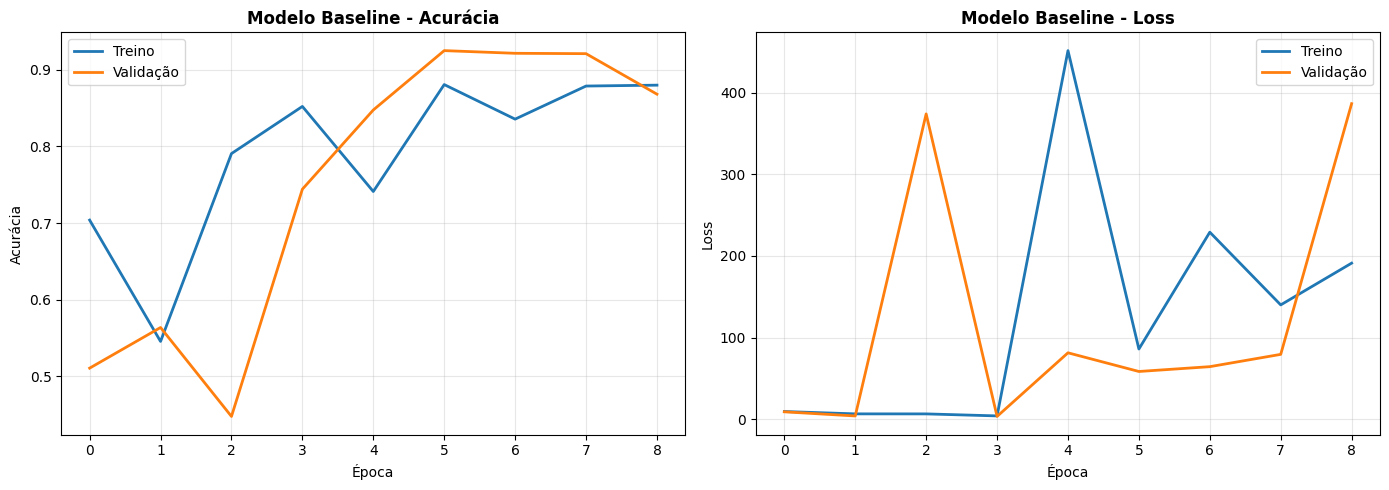

In [18]:
def plotar_historico(historico, nome_modelo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

   
    axes[0].plot(historico.history["accuracy"], label="Treino", linewidth=2)
    axes[0].plot(historico.history["val_accuracy"], label="Validação", linewidth=2)
    axes[0].set_title(f"{nome_modelo} - Acurácia", fontweight="bold")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Acurácia")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    
    axes[1].plot(historico.history["loss"], label="Treino", linewidth=2)
    axes[1].plot(historico.history["val_loss"], label="Validação", linewidth=2)
    axes[1].set_title(f"{nome_modelo} - Loss", fontweight="bold")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"{nome_modelo.lower().replace(' ', '_')}_curvas.png", dpi=100, bbox_inches="tight")
    plt.show()

plotar_historico(historico_baseline, "Modelo Baseline")

In [20]:
print("Avaliando Modelo Baseline no conjunto de TESTE...\n")
test_loss, test_acc = modelo_baseline.evaluate(test_ds, verbose=1)

print(f"\n RESULTADOS — Modelo Baseline")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")


import json
metricas_baseline = {
    "modelo": "BaselineCNN",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "epochs_treinadas": len(historico_baseline.history["loss"]),
    "tempo_minutos": tempo_total,
    "historico": {k: [float(v) for v in vals] for k, vals in historico_baseline.history.items()},
}

with open(REPORTS_DIR / "metricas_baseline.json", "w") as f:
    json.dump(metricas_baseline, f, indent=2)

print(f"\n Métricas salvas em reports/metricas_baseline.json")

Avaliando Modelo Baseline no conjunto de TESTE...

197/197 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7379 - loss: 3.3964

 RESULTADOS — Modelo Baseline
   Test Loss:     3.3964
   Test Accuracy: 0.7379 (73.79%)

 Métricas salvas em reports/metricas_baseline.json
